# DeepSVDD v2 — 低维特征实验

**Exp 1**: 窄带光谱 — 仅取 CN3839/CN4142/CH4300 三个分子带核心区域，~180 像素（无连续谱）

**Exp 2**: 物理特征 — 12 维标准化特征 (teff/logg/feh + CN3839/CN4142/CH4300 + delta_CN3839/CN4142/CH4300 + pca_1/2/3)

两者共享同一份全光谱数据加载，对比不同输入表示对 DeepSVDD 异常检测的影响。

In [1]:
import os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import warnings
warnings.filterwarnings('ignore')

_root = os.path.dirname(os.getcwd()) if 'Deep' in os.getcwd() else os.getcwd()
if _root not in sys.path:
    sys.path.insert(0, _root)
os.chdir(_root)

from Deep.config import DeepSVDDConfig
from Deep.data import (
    load_spectra_data,
    extract_narrow_band_spectra,
    compute_physics_features,
    NARROW_BAND_RANGES, NARROW_BAND_TOTAL_PIX,
)
from Deep.models import DeepSVDD
from Deep.train import DeepSVDDTrainer
from Deep.evaluate import evaluate_model, summarize_results

print(f'PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}')

PyTorch: 2.5.1+cu121, CUDA: True


In [2]:
# 加载全光谱数据（两个实验共享）
dataset_full = load_spectra_data(verbose=True)

Loading LAMOST spectra (segment normalisation)


100%|██████████| 48440/48440 [10:48<00:00, 74.74it/s] 



Pipeline summary:
  n_input: 48440
  n_after_dropna: 48440
  n_positive_labeled: 108
  n_loaded: 37086
  n_normalized_ok: 37086
  n_after_uid_dedup: 34123
  n_after_anomaly_filter: 33512
  n_positive (final): 73
  n_unlabeled (final): 33439
  Spectra shape: (33512, 5180)


---
## Experiment 1: 窄带光谱（~210 pixels）

仅保留 CN/CH 分子带所在波长区域，去除 98% 的不相关像素。
预期：信号集中在 ~200 像素，DeepSVDD 能更有效地区分 CN 增强星。

In [3]:
dataset_narrow = extract_narrow_band_spectra(dataset_full)
print(f'Narrow-band spectra: {dataset_narrow.X.shape}')
print(f'Band ranges: {NARROW_BAND_RANGES}')
print(f'Total pixels: {NARROW_BAND_TOTAL_PIX}')
print(f'Known CN: {dataset_narrow.n_positive}, Unlabeled: {dataset_narrow.n_unlabeled}')

Narrow-band spectra: (33512, 182)
Band ranges: [(3830, 3883), (4120, 4216), (4285, 4315)]
Total pixels: 179
Known CN: 73, Unlabeled: 33439


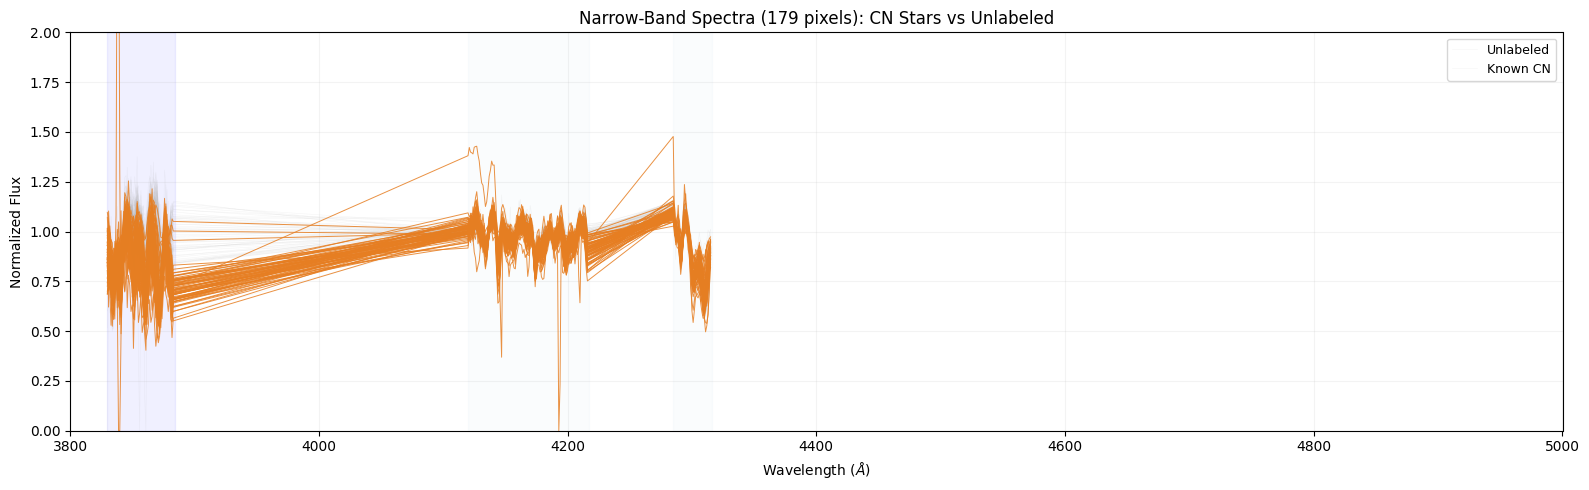

In [4]:
# 可视化窄带光谱：已知 CN vs 随机未标注
fig, ax = plt.subplots(figsize=(16, 5))

pos_idx = np.where(dataset_narrow.y == 1)[0]
unl_idx = np.where(dataset_narrow.y == -1)[0]
rng = np.random.RandomState(42)
unl_sample = rng.choice(unl_idx, size=min(200, len(unl_idx)), replace=False)

# Plot background
for idx in unl_sample[:80]:
    ax.plot(dataset_narrow.wave, dataset_narrow.X[idx],
            color='#b0b0b0', alpha=0.12, linewidth=0.4)

# Plot known CN
for idx in pos_idx:
    ax.plot(dataset_narrow.wave, dataset_narrow.X[idx],
            color='#e67e22', alpha=0.85, linewidth=0.7)

# Mark band regions
band_colors = ['blue', 'lightblue', 'lightblue', 'lightblue', 'green', 'red']
band_labels = ['CN3839 band', 'CN3839 blue', 'CN3839 red',
               'CN4142 blue', 'CN4142 band', 'CN4142 red/CH4300']
offset = 0
for (lo, hi), col, lab in zip(NARROW_BAND_RANGES, band_colors, band_labels):
    n = hi - lo
    ax.axvspan(lo, hi + 1, alpha=0.06, color=col, zorder=0)
    offset += n

ax.set_xlabel('Wavelength ($\\AA$)')
ax.set_ylabel('Normalized Flux')
ax.set_title(f'Narrow-Band Spectra ({NARROW_BAND_TOTAL_PIX} pixels): CN Stars vs Unlabeled')
ax.legend(['Unlabeled', 'Known CN'], fontsize=9)
ax.grid(alpha=0.15)
ax.set_ylim(0, 2)
ax.set_xlim(3800,5000)
plt.tight_layout()
plt.show()

In [5]:
# Exp 1 训练
print('='*60)
print('EXP 1: Narrow-Band Spectra (~180 pix, band cores only)')
print('='*60)

config1 = DeepSVDDConfig(
    input_dim=dataset_narrow.n_features,
    hidden_dims=[128, 64, 32],
    latent_dim=16,
    encoder_type='mlp',
    objective='soft-boundary',
    nu=0.05,
    learning_rate=3e-4,
    batch_size=256,
    n_epochs=150,
    early_stopping_patience=30,
    clean_cn_percentile=100.0,              # 窄带无连续谱，跳过 CN 预清洗
    device='cuda' if torch.cuda.is_available() else 'cpu',
)
print(f'Input: {config1.input_dim} pixels')

trainer1 = DeepSVDDTrainer(config1, save_dir='Deep/checkpoints/v2_narrow')
model1 = trainer1.train(dataset_narrow, verbose=True)

metrics1 = evaluate_model(model1, dataset_narrow, device=config1.device)
print(summarize_results(metrics1))

EXP 1: Narrow-Band Spectra (~180 pix, band cores only)
Input: 182 pixels
CN pre-clean: threshold=0.0000, removed 0 unlabeled (0.0%), known-CN median=0.0000
  Train samples (clean): 30,096 / 33,439 unlabeled
Model: 34,049 parameters
  Input: 182
  Hidden: [128, 64, 32]
  Latent: 16
  Encoder: mlp
  Objective: soft-boundary
Initializing hypersphere center...

Training for up to 150 epochs...
  Train samples: 30096
------------------------------------------------------------
Epoch  10/150 | loss: 0.0412 | val_loss: 0.0336 | lr: 3.00e-04 *
Epoch  20/150 | loss: 0.0276 | val_loss: 0.0203 | lr: 3.00e-04 *
Epoch  30/150 | loss: 0.0241 | val_loss: 0.0173 | lr: 3.00e-04 *
Epoch  40/150 | loss: 0.0223 | val_loss: 0.0161 | lr: 3.00e-04 *
Epoch  50/150 | loss: 0.0218 | val_loss: 0.0151 | lr: 3.00e-04 *
Epoch  60/150 | loss: 0.0215 | val_loss: 0.0152 | lr: 3.00e-04
Epoch  70/150 | loss: 0.0206 | val_loss: 0.0147 | lr: 1.50e-04
Epoch  80/150 | loss: 0.0213 | val_loss: 0.0147 | lr: 1.50e-04
Epoch  90

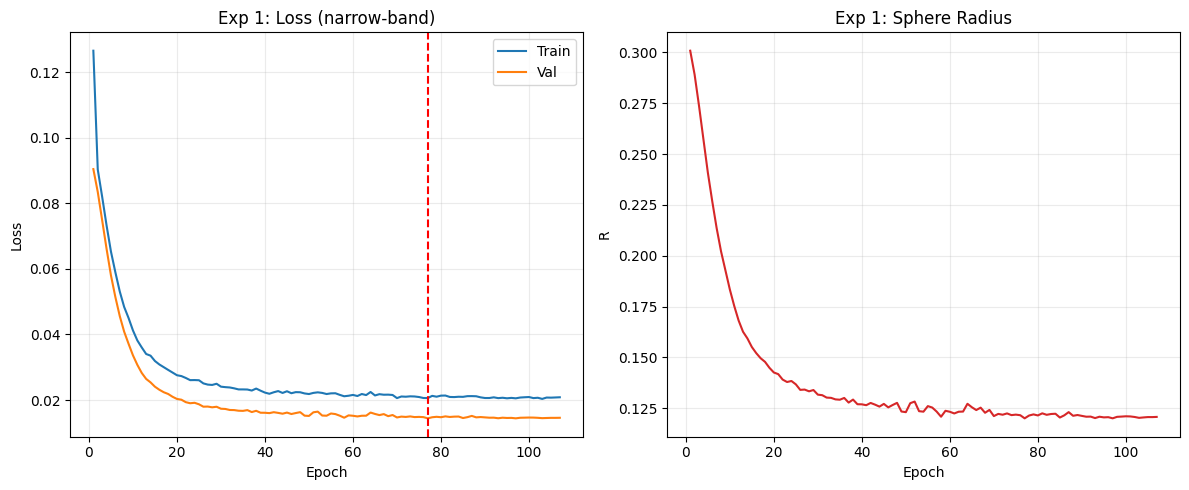

In [6]:
# Exp 1 训练曲线
h1 = trainer1.get_history_df()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(h1['epoch'], h1['train_loss'], label='Train')
axes[0].plot(h1['epoch'], h1['val_loss'], label='Val')
axes[0].axvline(h1.loc[h1['val_loss'].idxmin(), 'epoch'], color='red', linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Exp 1: Loss (narrow-band)')
axes[0].legend(); axes[0].grid(alpha=0.25)

axes[1].plot(h1['epoch'], h1['R'], color='tab:red')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('R')
axes[1].set_title('Exp 1: Sphere Radius')
axes[1].grid(alpha=0.25)
plt.tight_layout(); plt.show()

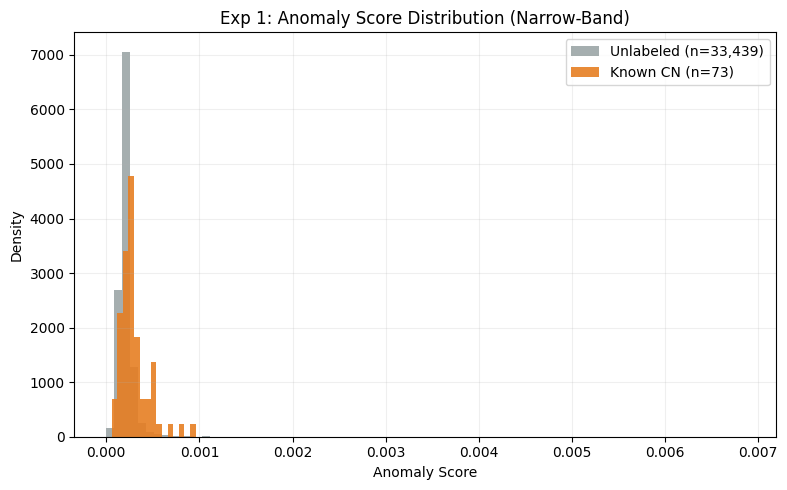

In [7]:
# Exp 1 异常分数分布
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(metrics1['scores_unlabeled'], bins=80, density=True, alpha=0.7,
        color='#7f8c8d', label=f'Unlabeled (n={len(metrics1["scores_unlabeled"]):,})')
ax.hist(metrics1['scores_positive'], bins=15, density=True, alpha=0.9,
        color='#e67e22', label=f'Known CN (n={len(metrics1["scores_positive"])})')
ax.set_xlabel('Anomaly Score'); ax.set_ylabel('Density')
ax.set_title('Exp 1: Anomaly Score Distribution (Narrow-Band)')
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

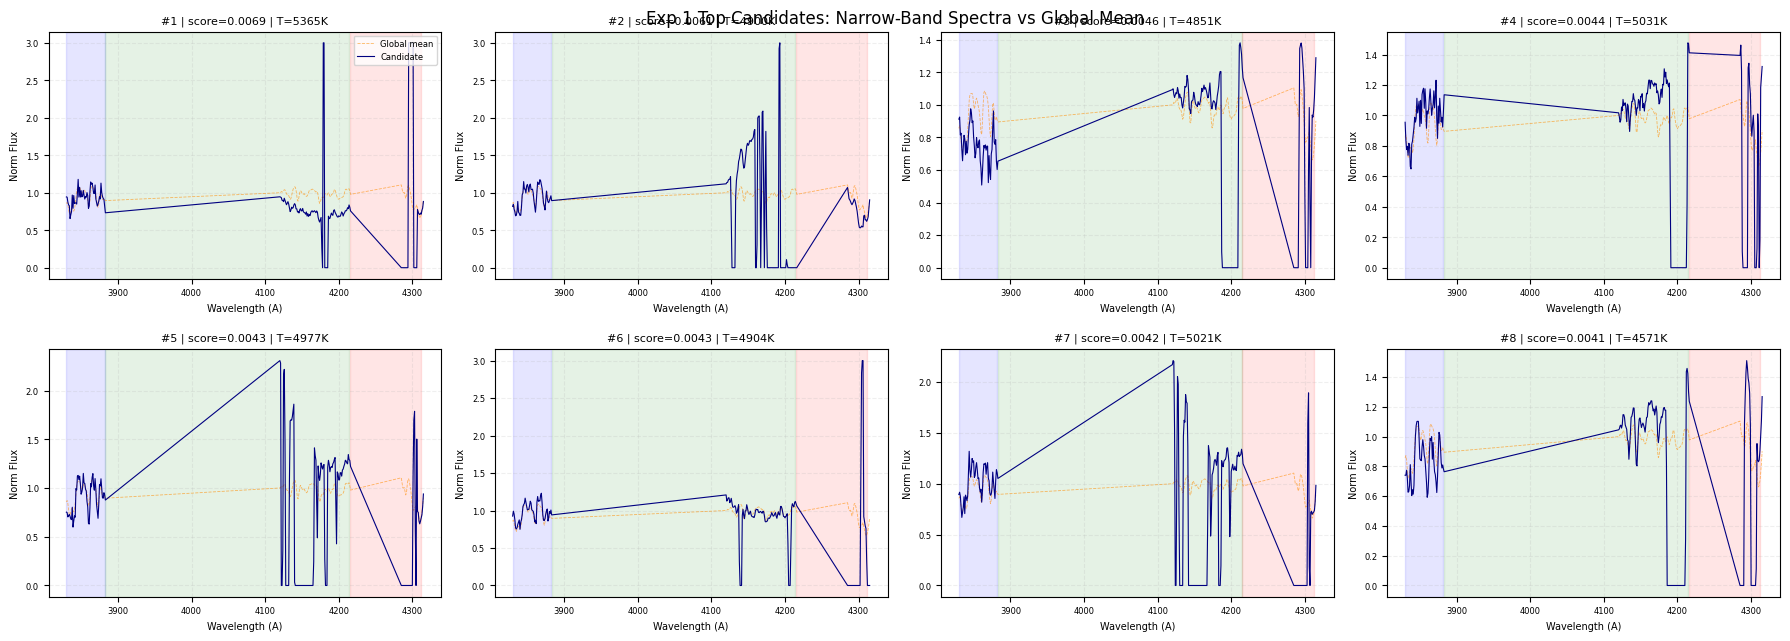

In [8]:
# Exp 1 候选窄带光谱可视化
from Deep.evaluate import select_candidates

cand1 = select_candidates(metrics1, top_n=12,
    output_csv='Deep/candidates_v2_narrow.csv')

TOP_N = 8
cand_viz = cand1.head(TOP_N)
n_cols = 4
n_rows = int(np.ceil(TOP_N / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.2 * n_rows))
axes = np.asarray(axes).reshape(-1)

# 全局平均窄带光谱
global_narrow = dataset_narrow.X.mean(axis=0)

for i, (_, row) in enumerate(cand_viz.iterrows()):
    ax = axes[i]
    idx = row.name

    # 分子带区域标记
    offset = 0
    for band_i, (lo, hi) in enumerate(NARROW_BAND_RANGES):
        n_pix = hi - lo
        colors = ['blue', 'green', 'red']
        ax.axvspan(dataset_narrow.wave[offset], dataset_narrow.wave[offset + n_pix - 1],
                   alpha=0.10, color=colors[band_i], zorder=0)
        offset += n_pix

    # 全局平均
    ax.plot(dataset_narrow.wave, global_narrow, color='darkorange', linewidth=0.6,
            linestyle='--', alpha=0.6, label='Global mean')
    # 候选
    if idx < len(dataset_narrow.X):
        ax.plot(dataset_narrow.wave, dataset_narrow.X[idx], color='navy', linewidth=0.8, label='Candidate')

    score = row.get('anomaly_score', np.nan)
    teff = row.get('teff', np.nan)
    ax.set_title(f'#{i+1} | score={score:.4f} | T={teff:.0f}K', fontsize=8)
    ax.set_xlabel('Wavelength (A)', fontsize=7)
    ax.set_ylabel('Norm Flux', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.2, linestyle='--')
    if i == 0:
        ax.legend(fontsize=6, loc='upper right')

for j in range(len(cand_viz), len(axes)):
    axes[j].axis('off')

fig.suptitle('Exp 1 Top Candidates: Narrow-Band Spectra vs Global Mean', fontsize=12, y=0.995)
plt.tight_layout()
plt.subplots_adjust(top=0.96)
plt.show()

AttributeError: 'NoneType' object has no attribute 'mean'

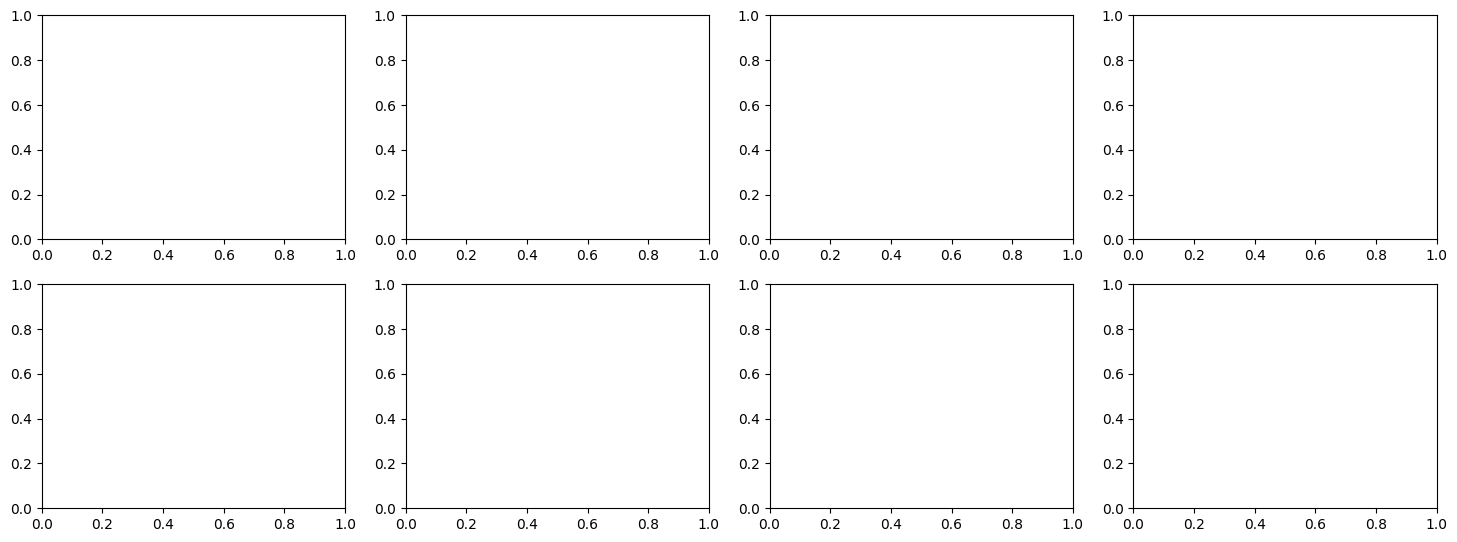

In [9]:
# Exp 1 候选窄带光谱可视化
from Deep.evaluate import select_candidates

cand1 = select_candidates(metrics1, top_n=12,
    output_csv='Deep/candidates_v2_narrow.csv')

TOP_N = 8
cand_viz = cand1.head(TOP_N)
n_cols = 4
n_rows = int(np.ceil(TOP_N / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.2 * n_rows))
axes = np.asarray(axes).reshape(-1)

# 全局平均窄带光谱
global_narrow = dataset_narrow.X_raw.mean(axis=0)

for i, (_, row) in enumerate(cand_viz.iterrows()):
    ax = axes[i]
    idx = row.name

    # 分子带区域标记
    offset = 0
    for band_i, (lo, hi) in enumerate(NARROW_BAND_RANGES):
        n_pix = hi - lo
        colors = ['blue', 'green', 'red']
        ax.axvspan(dataset_narrow.wave[offset], dataset_narrow.wave[offset + n_pix - 1],
                   alpha=0.10, color=colors[band_i], zorder=0)
        offset += n_pix

    # 全局平均
    # ax.plot(dataset_narrow.wave, global_narrow, color='darkorange', linewidth=0.6,
    #         linestyle='--', alpha=0.6, label='Global mean')
    # 候选
    if idx < len(dataset_narrow.X):
        ax.plot(dataset_narrow.wave, dataset_narrow.X_raw[idx], color='navy', linewidth=0.8, label='Candidate')

    score = row.get('anomaly_score', np.nan)
    teff = row.get('teff', np.nan)
    ax.set_title(f'#{i+1} | score={score:.4f} | T={teff:.0f}K', fontsize=8)
    ax.set_xlabel('Wavelength (A)', fontsize=7)
    ax.set_ylabel('Norm Flux', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.2, linestyle='--')
    if i == 0:
        ax.legend(fontsize=6, loc='upper right')

for j in range(len(cand_viz), len(axes)):
    axes[j].axis('off')

fig.suptitle('Exp 1 Top Candidates: Narrow-Band Spectra vs Global Mean', fontsize=12, y=0.995)
plt.tight_layout()
plt.subplots_adjust(top=0.96)
plt.show()

---
## Experiment 2: 物理特征 (12-D)

使用 12 维物理特征代替原始光谱：
- 3 恒星参数: teff, logg, feh
- 3 分子带指数: CN3839, CN4142, CH4300
- 3 KNN 差分特征: delta_CN3839, delta_CN4142, delta_CH4300
- 3 PCA 成分: pca_1, pca_2, pca_3

这些特征已经在之前 MLP 实验中验证有效，delta 特征直接捕捉 CN 增强信号。

In [ ]:
# 计算 12-D 物理特征
print('Computing physics features (KNN + band indices + PCA)...')
dataset_phys = compute_physics_features(dataset_full, n_pca=3, random_seed=42)
print(f'Physics features: {dataset_phys.X.shape}')
print(f'Feature names: {["teff","logg","feh","CN3839","CN4142","CH4300","delta_CN3839","delta_CN4142","delta_CH4300","pca_1","pca_2","pca_3"]}')
print(f'Known CN: {dataset_phys.n_positive}, Unlabeled: {dataset_phys.n_unlabeled}')

# Show feature stats for CN vs unlabeled
meta_phys = dataset_phys.meta
feat_names = ["delta_CN3839", "delta_CN4142", "delta_CH4300", "CN3839", "CN4142", "CH4300"]
print('\nFeature means (CN vs Unlabeled):')
for f in feat_names:
    if f in meta_phys.columns:
        cn_mean = meta_phys[meta_phys['label']==1][f].mean()
        unl_mean = meta_phys[meta_phys['label']==-1][f].mean()
        print(f'  {f:20s}: CN={cn_mean:.4f}, Unl={unl_mean:.4f}, diff={cn_mean-unl_mean:+.4f}')

Computing physics features (KNN + band indices + PCA)...
Physics features: (33512, 12)
Feature names: ['teff', 'logg', 'feh', 'CN3839', 'CN4142', 'CH4300', 'delta_CN3839', 'delta_CN4142', 'delta_CH4300', 'pca_1', 'pca_2', 'pca_3']
Known CN: 73, Unlabeled: 33439

Feature means (CN vs Unlabeled):
  delta_CN3839        : CN=2.2885, Unl=-0.0050, diff=+2.2935
  delta_CN4142        : CN=0.6848, Unl=-0.0015, diff=+0.6862
  delta_CH4300        : CN=-0.4091, Unl=0.0009, diff=-0.4100
  CN3839              : CN=1.3158, Unl=-0.0029, diff=+1.3187
  CN4142              : CN=1.1780, Unl=-0.0026, diff=+1.1806
  CH4300              : CN=0.2905, Unl=-0.0006, diff=+0.2911


In [ ]:
# Exp 2 训练
print('='*60)
print('EXP 2: Physics Features (12-D)')
print('='*60)

config2 = DeepSVDDConfig(
    input_dim=dataset_phys.n_features,
    hidden_dims=[64, 32],
    latent_dim=8,
    encoder_type='mlp',
    objective='soft-boundary',
    nu=0.05,
    learning_rate=1e-3,
    batch_size=256,
    n_epochs=200,
    early_stopping_patience=40,
    clean_cn_percentile=95.0,
    device='cuda' if torch.cuda.is_available() else 'cpu',
)
print(f'Input: {config2.input_dim} features')

trainer2 = DeepSVDDTrainer(config2, save_dir='Deep/checkpoints/v2_phys')
model2 = trainer2.train(dataset_phys, verbose=True)

metrics2 = evaluate_model(model2, dataset_phys, device=config2.device)
print(summarize_results(metrics2))

EXP 2: Physics Features (12-D)
Input: 12 features
CN pre-clean: threshold=0.0000, removed 0 unlabeled (0.0%), known-CN median=0.0000
  Train samples (clean): 30,096 / 33,439 unlabeled
Model: 3,073 parameters
  Input: 12
  Hidden: [64, 32]
  Latent: 8
  Encoder: mlp
  Objective: soft-boundary
Initializing hypersphere center...

Training for up to 200 epochs...
  Train samples: 30096
------------------------------------------------------------
Epoch  10/200 | loss: 0.0480 | val_loss: 0.0366 | lr: 1.00e-03 *
Epoch  20/200 | loss: 0.0366 | val_loss: 0.0287 | lr: 1.00e-03 *
Epoch  30/200 | loss: 0.0311 | val_loss: 0.0250 | lr: 1.00e-03
Epoch  40/200 | loss: 0.0286 | val_loss: 0.0233 | lr: 1.00e-03
Epoch  50/200 | loss: 0.0268 | val_loss: 0.0206 | lr: 1.00e-03
Epoch  60/200 | loss: 0.0256 | val_loss: 0.0203 | lr: 1.00e-03
Epoch  70/200 | loss: 0.0252 | val_loss: 0.0208 | lr: 1.00e-03
Epoch  80/200 | loss: 0.0238 | val_loss: 0.0189 | lr: 5.00e-04 *
Epoch  90/200 | loss: 0.0236 | val_loss: 0.0

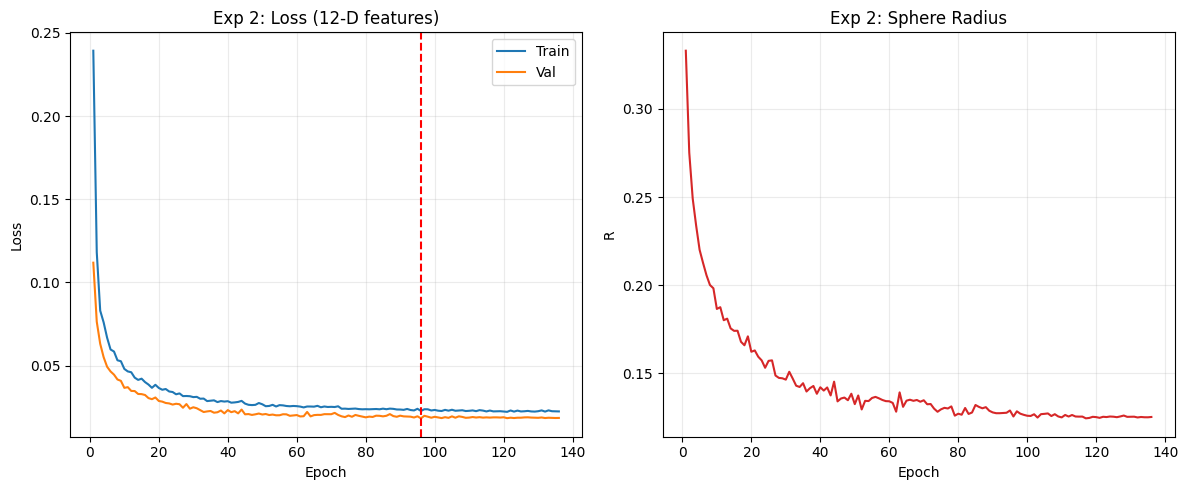

In [ ]:
# Exp 2 训练曲线
h2 = trainer2.get_history_df()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(h2['epoch'], h2['train_loss'], label='Train')
axes[0].plot(h2['epoch'], h2['val_loss'], label='Val')
axes[0].axvline(h2.loc[h2['val_loss'].idxmin(), 'epoch'], color='red', linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Exp 2: Loss (12-D features)')
axes[0].legend(); axes[0].grid(alpha=0.25)

axes[1].plot(h2['epoch'], h2['R'], color='tab:red')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('R')
axes[1].set_title('Exp 2: Sphere Radius')
axes[1].grid(alpha=0.25)
plt.tight_layout(); plt.show()

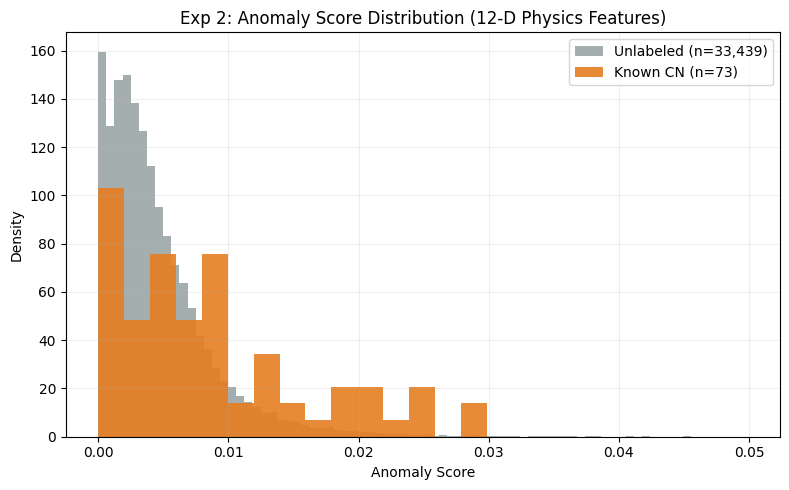

KS test: statistic=0.3262, p-value=2.03e-07


In [ ]:
# Exp 2 异常分数分布
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(metrics2['scores_unlabeled'], bins=80, density=True, alpha=0.7,
        color='#7f8c8d', label=f'Unlabeled (n={len(metrics2["scores_unlabeled"]):,})')
ax.hist(metrics2['scores_positive'], bins=15, density=True, alpha=0.9,
        color='#e67e22', label=f'Known CN (n={len(metrics2["scores_positive"])})')
ax.set_xlabel('Anomaly Score'); ax.set_ylabel('Density')
ax.set_title('Exp 2: Anomaly Score Distribution (12-D Physics Features)')
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

# KS test
from scipy.stats import ks_2samp
ks_stat, ks_pval = ks_2samp(metrics2['scores_positive'], metrics2['scores_unlabeled'])
print(f'KS test: statistic={ks_stat:.4f}, p-value={ks_pval:.2e}')

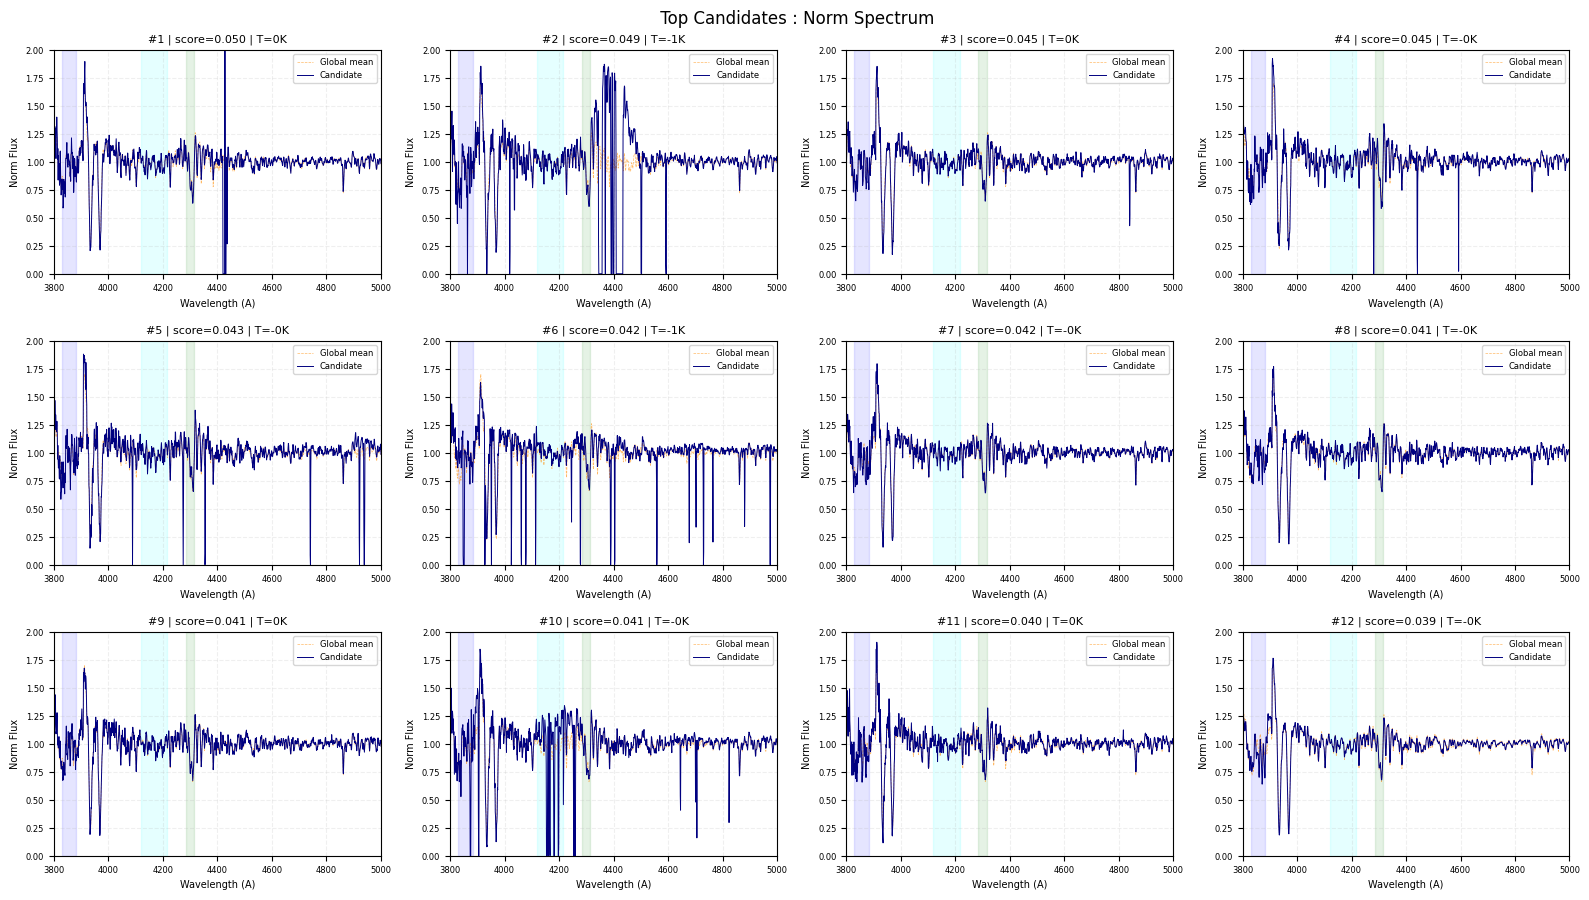

In [ ]:
# Exp 2 候选全光谱可视化（用 dataset_full.X 展示物理特征 Top 候选的完整光谱）
cand2 = select_candidates(metrics2, top_n=12,
    output_csv='Deep/candidates_v2_phys.csv')

TOP_N = 12
cand_viz2 = cand2.head(TOP_N)
global_full = dataset_full.X.mean(axis=0)

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
axes = axes.flatten()

for i, (_, row) in enumerate(cand_viz2.iterrows()):
    ax = axes[i]
    idx = row.name

    # 分子带 + 辅助证认线
    ax.axvspan(3830, 3883, alpha=0.10, color='blue', zorder=0)
    ax.axvspan(4120, 4216, alpha=0.10, color='cyan', zorder=0)
    ax.axvspan(4285, 4315, alpha=0.10, color='green', zorder=0)
    ax.axvspan(5160, 5190, alpha=0.08, color='orange', zorder=0)  # Mg b
    ax.axvspan(5880, 5910, alpha=0.08, color='red', zorder=0)     # Na D
    ax.axvspan(8480, 8670, alpha=0.08, color='purple', zorder=0)  # Ca II

    ax.plot(dataset_full.wave, global_full, color='darkorange', linewidth=0.5,
            linestyle='--', alpha=0.6, label='Global mean')

    if idx < len(dataset_full.X):
        ax.plot(dataset_full.wave, dataset_full.X[idx], color='navy', linewidth=0.7, label='Candidate')

    score = row.get('anomaly_score', np.nan)
    teff = row.get('teff', np.nan)
    logg = row.get('logg', np.nan)
    feh = row.get('feh', np.nan)
    ax.set_title(f'#{i+1} | score={score:.3f} | T={teff:.0f}K', fontsize=8)
    ax.set_xlabel('Wavelength (A)', fontsize=7)
    ax.set_ylabel('Norm Flux', fontsize=7)
    ax.set_ylim(0, 2)
    ax.set_xlim(3800, 5000)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.2, linestyle='--')
    ax.legend(fontsize=6, loc='upper right')

for j in range(TOP_N, 8):
    axes[j].axis('off')

fig.suptitle(' Top Candidates : Norm Spectrum', fontsize=12, y=0.995)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

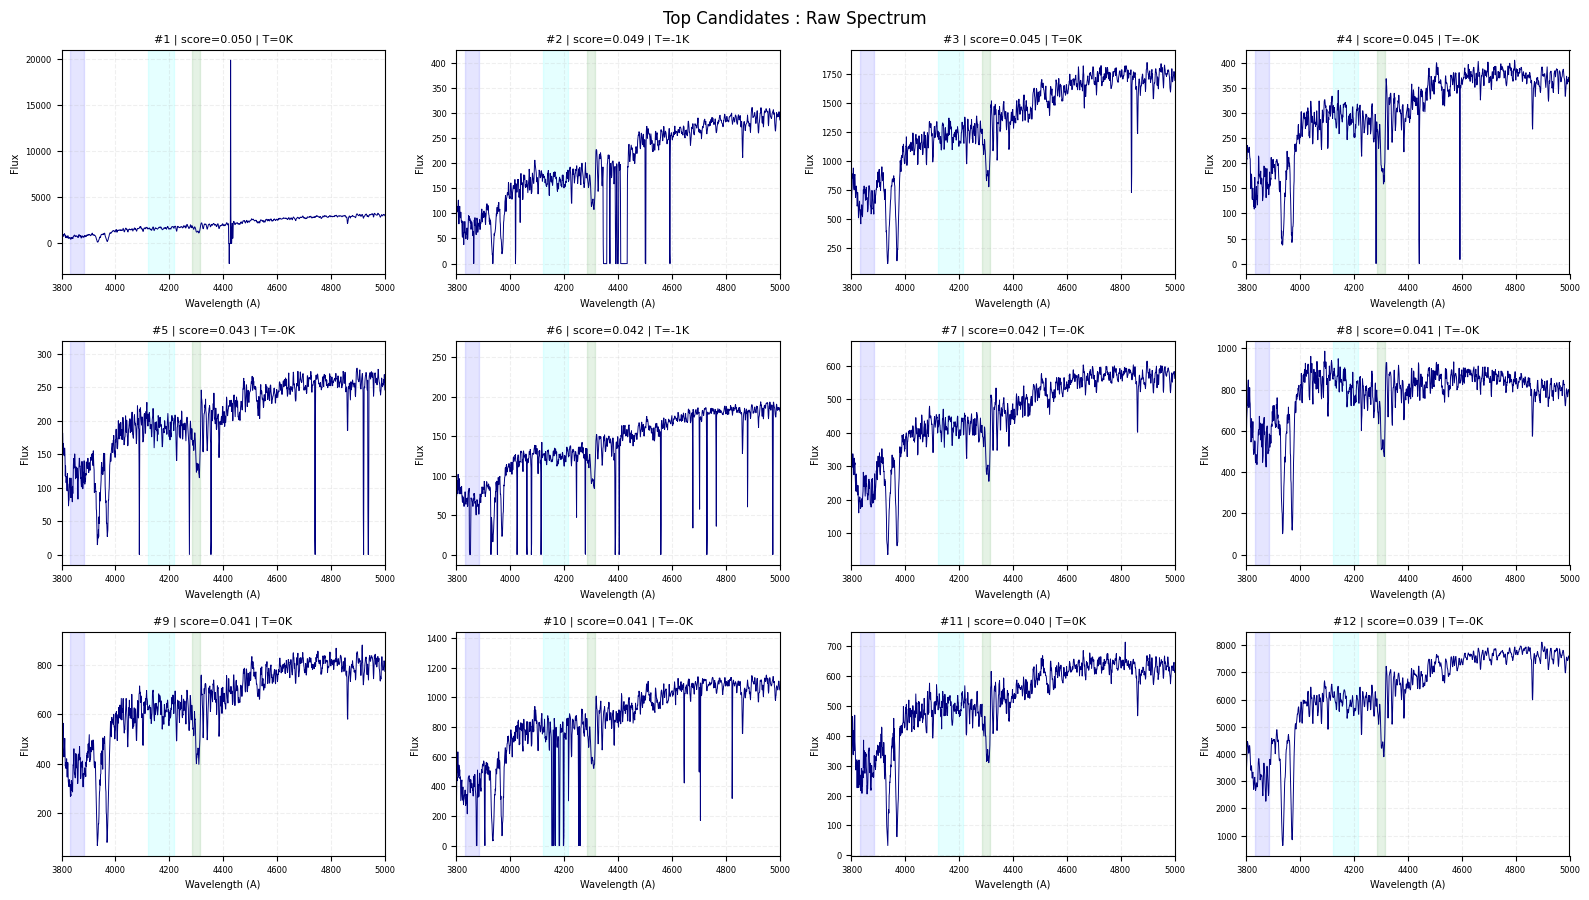

In [ ]:
# 候选原始光谱可视化
cand2 = select_candidates(metrics2, top_n=12,
    output_csv='Deep/candidates_v2_phys.csv')

TOP_N = 12
cand_viz2 = cand2.head(TOP_N)
global_full = dataset_full.X_raw.mean(axis=0)

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
axes = axes.flatten()

for i, (_, row) in enumerate(cand_viz2.iterrows()):
    ax = axes[i]
    idx = row.name

    # 分子带 + 辅助证认线
    ax.axvspan(3830, 3883, alpha=0.10, color='blue', zorder=0)
    ax.axvspan(4120, 4216, alpha=0.10, color='cyan', zorder=0)
    ax.axvspan(4285, 4315, alpha=0.10, color='green', zorder=0)
    ax.axvspan(5160, 5190, alpha=0.08, color='orange', zorder=0)  # Mg b
    ax.axvspan(5880, 5910, alpha=0.08, color='red', zorder=0)     # Na D
    ax.axvspan(8480, 8670, alpha=0.08, color='purple', zorder=0)  # Ca II

    # ax.plot(dataset_full.wave, global_full, color='darkorange', linewidth=0.5,
    #         linestyle='--', alpha=0.6, label='Global mean')

    if idx < len(dataset_full.X_raw):
        ax.plot(dataset_full.wave, dataset_full.X_raw[idx], color='navy', linewidth=0.7, label='Candidate')

    score = row.get('anomaly_score', np.nan)
    teff = row.get('teff', np.nan)
    logg = row.get('logg', np.nan)
    feh = row.get('feh', np.nan)
    ax.set_title(f'#{i+1} | score={score:.3f} | T={teff:.0f}K', fontsize=8)
    ax.set_xlabel('Wavelength (A)', fontsize=7)
    ax.set_ylabel('Flux', fontsize=7)
    ax.set_xlim(3800, 5000)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.2, linestyle='--')

for j in range(TOP_N, 8):
    axes[j].axis('off')

fig.suptitle('Top Candidates : Raw Spectrum', fontsize=12, y=0.995)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()